# Building Population & Type Prediction — Multi-Task CNN

This notebook trains a multi-task model that takes a **building crop image + binary polygon mask**
and jointly predicts:
1. **Population count** (regression)
2. **Building type** (5-class classification)

The training data is generated by `building_population_pipeline.ipynb`.

**Architecture**: Modified EfficientNet-B0 with 4-channel input (RGB + mask),
shared backbone, and two task-specific heads.

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import (
    confusion_matrix, classification_report, mean_absolute_error,
    mean_squared_error, r2_score,
)
from sklearn.model_selection import GroupShuffleSplit

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
  GPU: NVIDIA RTX A6000
  Memory: 50.9 GB


In [2]:
# ── Configuration ──────────────────────────────────────────────────────────

DATA_DIR    = Path("ml_dataset")
LABELS_CSV  = DATA_DIR / "labels.csv"

IMG_SIZE      = 224          # resize crops to this square size
BATCH_SIZE    = 64
NUM_WORKERS   = 4
NUM_CLASSES   = 5
LR            = 1e-4
EPOCHS        = 50
PATIENCE      = 10           # early stopping patience
ALPHA         = 1.0          # weight for population loss (MSE on log-pop)
BETA          = 0.5          # weight for building-type loss (CE)

CLASS_NAMES = ["residential_small", "residential_multi", "commercial",
               "institutional", "other"]

print("Configuration loaded")

Configuration loaded


## 1 — Load labels & train/test split

In [3]:
df = pd.read_csv(LABELS_CSV)
print(f"Total samples: {len(df)}")
print(f"Tiles: {df['tile_base'].nunique()}")
print(f"\nPopulation stats:")
print(df["estimated_population"].describe().round(1))
print(f"\nClass distribution:")
print(df["type_class_name"].value_counts())

Total samples: 23014
Tiles: 300

Population stats:
count    23014.0
mean       289.6
std        880.8
min          0.0
25%        101.5
50%        215.8
75%        302.1
max      77234.1
Name: estimated_population, dtype: float64

Class distribution:
type_class_name
commercial           17392
residential_multi     3687
other                  954
institutional          632
residential_small      349
Name: count, dtype: int64


In [4]:
# Split by tile (not by building) to prevent spatial leakage.
# All buildings from a given satellite tile go into either train or test.

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(gss.split(df, groups=df["tile_base"]))

train_df = df.iloc[train_idx].reset_index(drop=True)
test_df  = df.iloc[test_idx].reset_index(drop=True)

print(f"Train: {len(train_df)} buildings from {train_df['tile_base'].nunique()} tiles")
print(f"Test:  {len(test_df)} buildings from {test_df['tile_base'].nunique()} tiles")
print(f"\nTrain class distribution:")
print(train_df["type_class_name"].value_counts())
print(f"\nTest class distribution:")
print(test_df["type_class_name"].value_counts())

Train: 18290 buildings from 240 tiles
Test:  4724 buildings from 60 tiles

Train class distribution:
type_class_name
commercial           13808
residential_multi     2878
other                  797
institutional          516
residential_small      291
Name: count, dtype: int64

Test class distribution:
type_class_name
commercial           3584
residential_multi     809
other                 157
institutional         116
residential_small      58
Name: count, dtype: int64


## 2 — PyTorch Dataset

In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


class BuildingDataset(Dataset):
    """4-channel (RGB + mask) dataset for building population prediction."""

    def __init__(self, dataframe, img_size=128, augment=False):
        self.df = dataframe.reset_index(drop=True)
        self.img_size = img_size
        self.augment = augment

        # Pre-compute log-transformed population targets
        self.pop_targets = torch.tensor(
            np.log1p(self.df["estimated_population"].values).astype(np.float32)
        )
        self.type_targets = torch.tensor(
            self.df["type_class"].values.astype(np.int64)
        )

        self.rgb_transforms_train = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
        self.rgb_transforms_val = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
        self.mask_transforms = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),   # scales [0,255] → [0,1]
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        rgb  = Image.open(row["crop_path"]).convert("RGB")
        mask = Image.open(row["mask_path"]).convert("L")

        if self.augment:
            # Apply same random seed for geometric augmentations
            seed = random.randint(0, 2**32 - 1)
            torch.manual_seed(seed)
            random.seed(seed)
            rgb_t = self.rgb_transforms_train(rgb)
            torch.manual_seed(seed)
            random.seed(seed)
            mask_t = self.mask_transforms(mask)
        else:
            rgb_t  = self.rgb_transforms_val(rgb)
            mask_t = self.mask_transforms(mask)

        x = torch.cat([rgb_t, mask_t], dim=0)  # (4, H, W)

        return x, self.pop_targets[idx], self.type_targets[idx]


train_ds = BuildingDataset(train_df, IMG_SIZE, augment=True)
test_ds  = BuildingDataset(test_df,  IMG_SIZE, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# Quick check
x, pop, typ = train_ds[0]
print(f"Input shape : {x.shape}  (4 channels: RGB + mask)")
print(f"Pop target  : {pop.item():.2f}  (log1p scale)")
print(f"Type target : {typ.item()}  ({CLASS_NAMES[typ.item()]})")
print(f"\nTrain batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Input shape : torch.Size([4, 224, 224])  (4 channels: RGB + mask)
Pop target  : 4.45  (log1p scale)
Type target : 2  (commercial)

Train batches: 286, Test batches: 74


## 3 — Multi-Task EfficientNet-B0 Model

In [6]:
class BuildingPopulationModel(nn.Module):
    """Multi-task EfficientNet-B0 with 4-channel input.

    Outputs:
        pop_logpop : (B,) — predicted log1p(population)
        type_logits: (B, NUM_CLASSES) — building type logits
    """

    def __init__(self, num_classes=5, pretrained=True):
        super().__init__()

        backbone = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        )

        # Expand the first conv from 3 → 4 input channels.
        # Copy pretrained RGB weights; init mask channel to zero.
        old_conv = backbone.features[0][0]
        new_conv = nn.Conv2d(
            4, old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=old_conv.bias is not None,
        )
        with torch.no_grad():
            new_conv.weight[:, :3] = old_conv.weight
            new_conv.weight[:, 3:] = 0.0
            if old_conv.bias is not None:
                new_conv.bias = old_conv.bias
        backbone.features[0][0] = new_conv

        # Extract feature layers (drop original classifier)
        self.features = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        feat_dim = backbone.classifier[1].in_features  # 1280 for B0

        # Shared projection
        self.shared_fc = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(feat_dim, 512),
            nn.ReLU(inplace=True),
        )

        # Population regression head
        self.pop_head = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 1),
        )

        # Building type classification head
        self.type_head = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)
        x = self.shared_fc(x)
        pop_logpop  = self.pop_head(x).squeeze(-1)
        type_logits = self.type_head(x)
        return pop_logpop, type_logits


model = BuildingPopulationModel(num_classes=NUM_CLASSES, pretrained=True).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: BuildingPopulationModel (EfficientNet-B0, 4-ch)")
print(f"  Total params    : {total_params:,}")
print(f"  Trainable params: {train_params:,}")

Model: BuildingPopulationModel (EfficientNet-B0, 4-ch)
  Total params    : 4,795,810
  Trainable params: 4,795,810


## 4 — Training Loop

In [8]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

pop_criterion  = nn.MSELoss()
type_criterion = nn.CrossEntropyLoss()


def run_epoch(loader, model, optimizer=None, train=True):
    """Run one epoch. Returns dict of metrics."""
    model.train() if train else model.eval()

    total_loss, total_pop_loss, total_type_loss = 0.0, 0.0, 0.0
    all_pop_pred, all_pop_true = [], []
    all_type_pred, all_type_true = [], []
    n = 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, pop_target, type_target in loader:
            x = x.to(DEVICE)
            pop_target  = pop_target.to(DEVICE)
            type_target = type_target.to(DEVICE)

            pop_pred, type_logits = model(x)

            loss_pop  = pop_criterion(pop_pred, pop_target)
            loss_type = type_criterion(type_logits, type_target)
            loss = ALPHA * loss_pop + BETA * loss_type

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            bs = x.size(0)
            total_loss      += loss.item() * bs
            total_pop_loss  += loss_pop.item() * bs
            total_type_loss += loss_type.item() * bs
            n += bs

            all_pop_pred.extend(pop_pred.detach().cpu().numpy())
            all_pop_true.extend(pop_target.detach().cpu().numpy())
            all_type_pred.extend(type_logits.argmax(dim=1).detach().cpu().numpy())
            all_type_true.extend(type_target.detach().cpu().numpy())

    all_pop_pred = np.array(all_pop_pred)
    all_pop_true = np.array(all_pop_true)

    # Convert from log1p back to real population for MAE
    pop_pred_real = np.expm1(all_pop_pred)
    pop_true_real = np.expm1(all_pop_true)

    type_acc = np.mean(np.array(all_type_pred) == np.array(all_type_true))

    return {
        "loss":      total_loss / n,
        "pop_loss":  total_pop_loss / n,
        "type_loss": total_type_loss / n,
        "pop_mae":   mean_absolute_error(pop_true_real, pop_pred_real),
        "pop_rmse":  np.sqrt(mean_squared_error(pop_true_real, pop_pred_real)),
        "pop_r2":    r2_score(pop_true_real, pop_pred_real) if len(set(pop_true_real)) > 1 else 0.0,
        "type_acc":  type_acc,
        "pop_pred_real": pop_pred_real,
        "pop_true_real": pop_true_real,
        "type_pred": np.array(all_type_pred),
        "type_true": np.array(all_type_true),
    }

print("Training functions defined")

Training functions defined


In [9]:
# ── Training loop with early stopping ──────────────────────────────────────

best_val_loss = float("inf")
patience_counter = 0
history = {"train": [], "val": []}

print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Val Loss':>10}  "
      f"{'Pop MAE':>8}  {'Pop R²':>7}  {'Type Acc':>8}  {'LR':>9}")
print("-" * 75)

for epoch in range(1, EPOCHS + 1):
    train_metrics = run_epoch(train_loader, model, optimizer, train=True)
    val_metrics   = run_epoch(test_loader,  model, train=False)

    history["train"].append(train_metrics)
    history["val"].append(val_metrics)

    cur_lr = optimizer.param_groups[0]["lr"]
    print(f"{epoch:5d}  {train_metrics['loss']:10.4f}  {val_metrics['loss']:10.4f}  "
          f"{val_metrics['pop_mae']:8.1f}  {val_metrics['pop_r2']:7.3f}  "
          f"{val_metrics['type_acc']:8.3f}  {cur_lr:9.2e}")

    scheduler.step(val_metrics["loss"])

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} (patience={PATIENCE})")
            break

print(f"\nBest validation loss: {best_val_loss:.4f}")
print("Model saved to best_model.pt")

Epoch  Train Loss    Val Loss   Pop MAE   Pop R²  Type Acc         LR
---------------------------------------------------------------------------
    1      3.1335      1.2738     167.6    0.369     0.759   1.00e-04
    2      0.9808      1.1284     164.5    0.117     0.776   1.00e-04
    3      0.8789      1.1187     177.6   -0.223     0.786   1.00e-04
    4      0.8109      1.0562     161.2    0.302     0.830   1.00e-04
    5      0.7588      0.9941     177.9   -0.129     0.832   1.00e-04
    6      0.7259      1.0057     280.8   -6.281     0.836   1.00e-04
    7      0.6666      0.9368     142.2    0.373     0.854   1.00e-04
    8      0.6230      0.9418     163.1   -0.151     0.857   1.00e-04
    9      0.5880      0.8669     127.5    0.447     0.865   1.00e-04
   10      0.5625      0.9708     201.1   -1.171     0.862   1.00e-04
   11      0.5333      0.8856     128.7    0.404     0.852   1.00e-04
   12      0.4996      1.0384     251.7   -2.654     0.858   1.00e-04
   13      0.4

## 5 — Training Curves

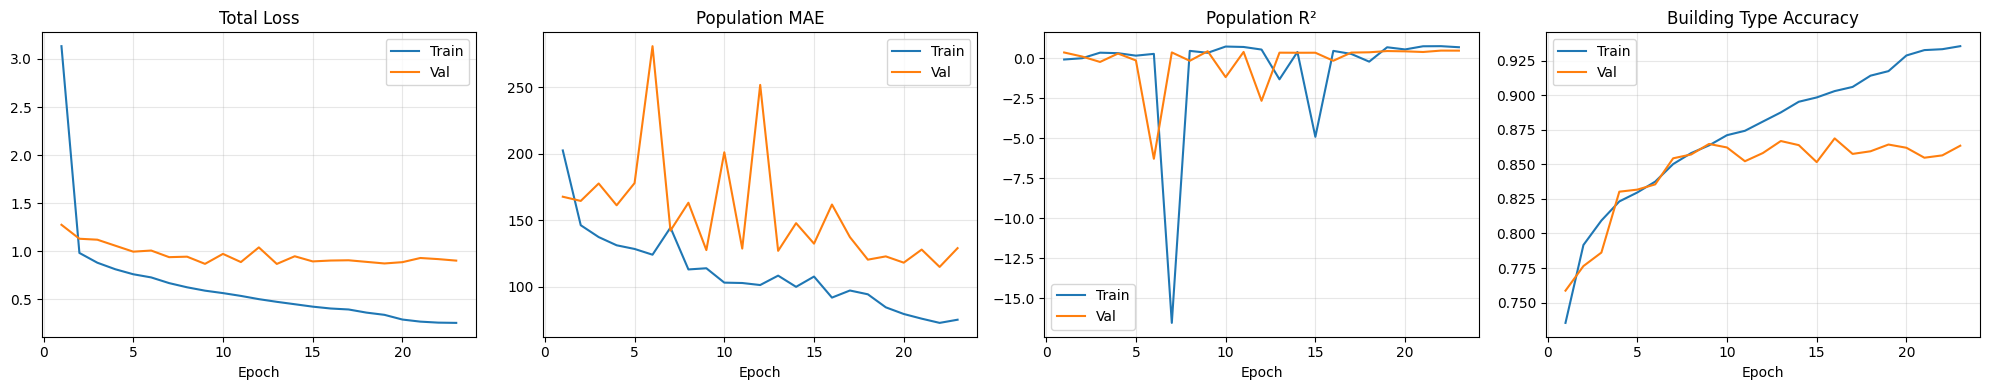

In [10]:
def plot_history(history):
    epochs = range(1, len(history["train"]) + 1)

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    # Total loss
    axes[0].plot(epochs, [m["loss"] for m in history["train"]], label="Train")
    axes[0].plot(epochs, [m["loss"] for m in history["val"]],   label="Val")
    axes[0].set_title("Total Loss")
    axes[0].legend()

    # Population MAE
    axes[1].plot(epochs, [m["pop_mae"] for m in history["train"]], label="Train")
    axes[1].plot(epochs, [m["pop_mae"] for m in history["val"]],   label="Val")
    axes[1].set_title("Population MAE")
    axes[1].legend()

    # Population R²
    axes[2].plot(epochs, [m["pop_r2"] for m in history["train"]], label="Train")
    axes[2].plot(epochs, [m["pop_r2"] for m in history["val"]],   label="Val")
    axes[2].set_title("Population R²")
    axes[2].legend()

    # Type accuracy
    axes[3].plot(epochs, [m["type_acc"] for m in history["train"]], label="Train")
    axes[3].plot(epochs, [m["type_acc"] for m in history["val"]],   label="Val")
    axes[3].set_title("Building Type Accuracy")
    axes[3].legend()

    for ax in axes:
        ax.set_xlabel("Epoch")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history)

## 6 — Evaluation on Test Set

In [11]:
# Load best model and evaluate
model.load_state_dict(torch.load("best_model.pt", map_location=DEVICE, weights_only=True))
test_metrics = run_epoch(test_loader, model, train=False)

print("=" * 50)
print("TEST SET RESULTS")
print("=" * 50)
print(f"\nPopulation regression:")
print(f"  MAE  : {test_metrics['pop_mae']:.1f} people")
print(f"  RMSE : {test_metrics['pop_rmse']:.1f} people")
print(f"  R²   : {test_metrics['pop_r2']:.3f}")
print(f"\nBuilding type classification:")
print(f"  Accuracy: {test_metrics['type_acc']:.3f}")
print(f"\nPer-class report:")
print(classification_report(
    test_metrics["type_true"], test_metrics["type_pred"],
    target_names=CLASS_NAMES, zero_division=0,
))

TEST SET RESULTS

Population regression:
  MAE  : 127.0 people
  RMSE : 652.5 people
  R²   : 0.357

Building type classification:
  Accuracy: 0.867

Per-class report:
                   precision    recall  f1-score   support

residential_small       0.66      0.76      0.70        58
residential_multi       0.77      0.67      0.72       809
       commercial       0.90      0.97      0.93      3584
    institutional       0.57      0.03      0.07       116
            other       0.47      0.25      0.33       157

         accuracy                           0.87      4724
        macro avg       0.67      0.54      0.55      4724
     weighted avg       0.85      0.87      0.85      4724



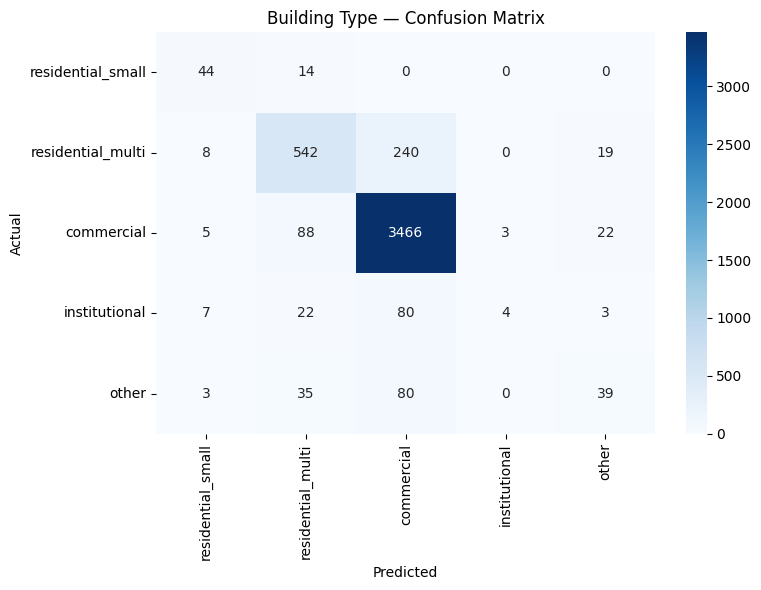

In [12]:
# Confusion matrix
cm = confusion_matrix(test_metrics["type_true"], test_metrics["type_pred"])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Building Type — Confusion Matrix")
plt.tight_layout()
plt.show()

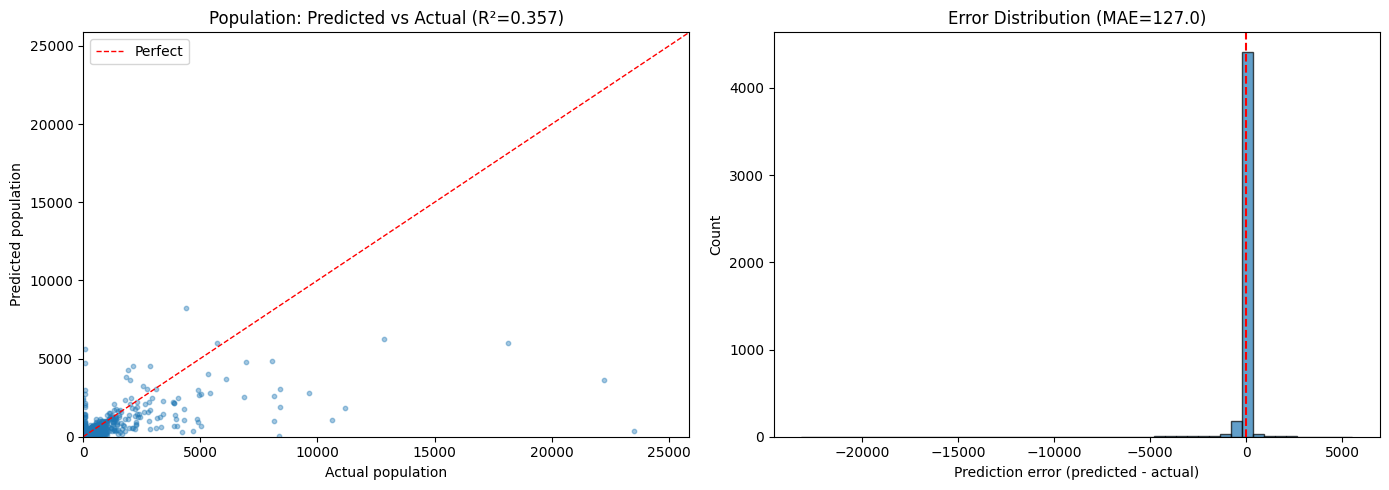

In [13]:
# Population: predicted vs actual scatter plot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
pred = test_metrics["pop_pred_real"]
true = test_metrics["pop_true_real"]
max_val = max(pred.max(), true.max()) * 1.1

axes[0].scatter(true, pred, alpha=0.4, s=10)
axes[0].plot([0, max_val], [0, max_val], "r--", linewidth=1, label="Perfect")
axes[0].set_xlabel("Actual population")
axes[0].set_ylabel("Predicted population")
axes[0].set_title(f"Population: Predicted vs Actual (R²={test_metrics['pop_r2']:.3f})")
axes[0].legend()
axes[0].set_xlim(0, max_val)
axes[0].set_ylim(0, max_val)

# Error distribution
errors = pred - true
axes[1].hist(errors, bins=50, edgecolor="k", alpha=0.7)
axes[1].axvline(0, color="r", linestyle="--")
axes[1].set_xlabel("Prediction error (predicted - actual)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Error Distribution (MAE={test_metrics['pop_mae']:.1f})")

plt.tight_layout()
plt.show()

In [14]:
# Per-building-type population error breakdown

test_df_eval = test_df.copy()
test_df_eval["pop_predicted"] = test_metrics["pop_pred_real"]
test_df_eval["pop_error"]     = test_df_eval["pop_predicted"] - test_df_eval["estimated_population"]
test_df_eval["pop_abs_error"] = test_df_eval["pop_error"].abs()

type_errors = test_df_eval.groupby("type_class_name").agg(
    n=("building_uid", "count"),
    mae=("pop_abs_error", "mean"),
    median_ae=("pop_abs_error", "median"),
    mean_actual=("estimated_population", "mean"),
).round(1)

print("Population MAE by building type:")
print(type_errors)

Population MAE by building type:
                      n    mae  median_ae  mean_actual
type_class_name                                       
commercial         3584  107.8       42.1        345.3
institutional       116  971.9       85.8       1397.8
other               157  144.2       71.2         61.8
residential_multi   809   96.1       14.6         39.1
residential_small    58    2.9        1.2          2.7


## 7 — Visual Predictions on Test Buildings

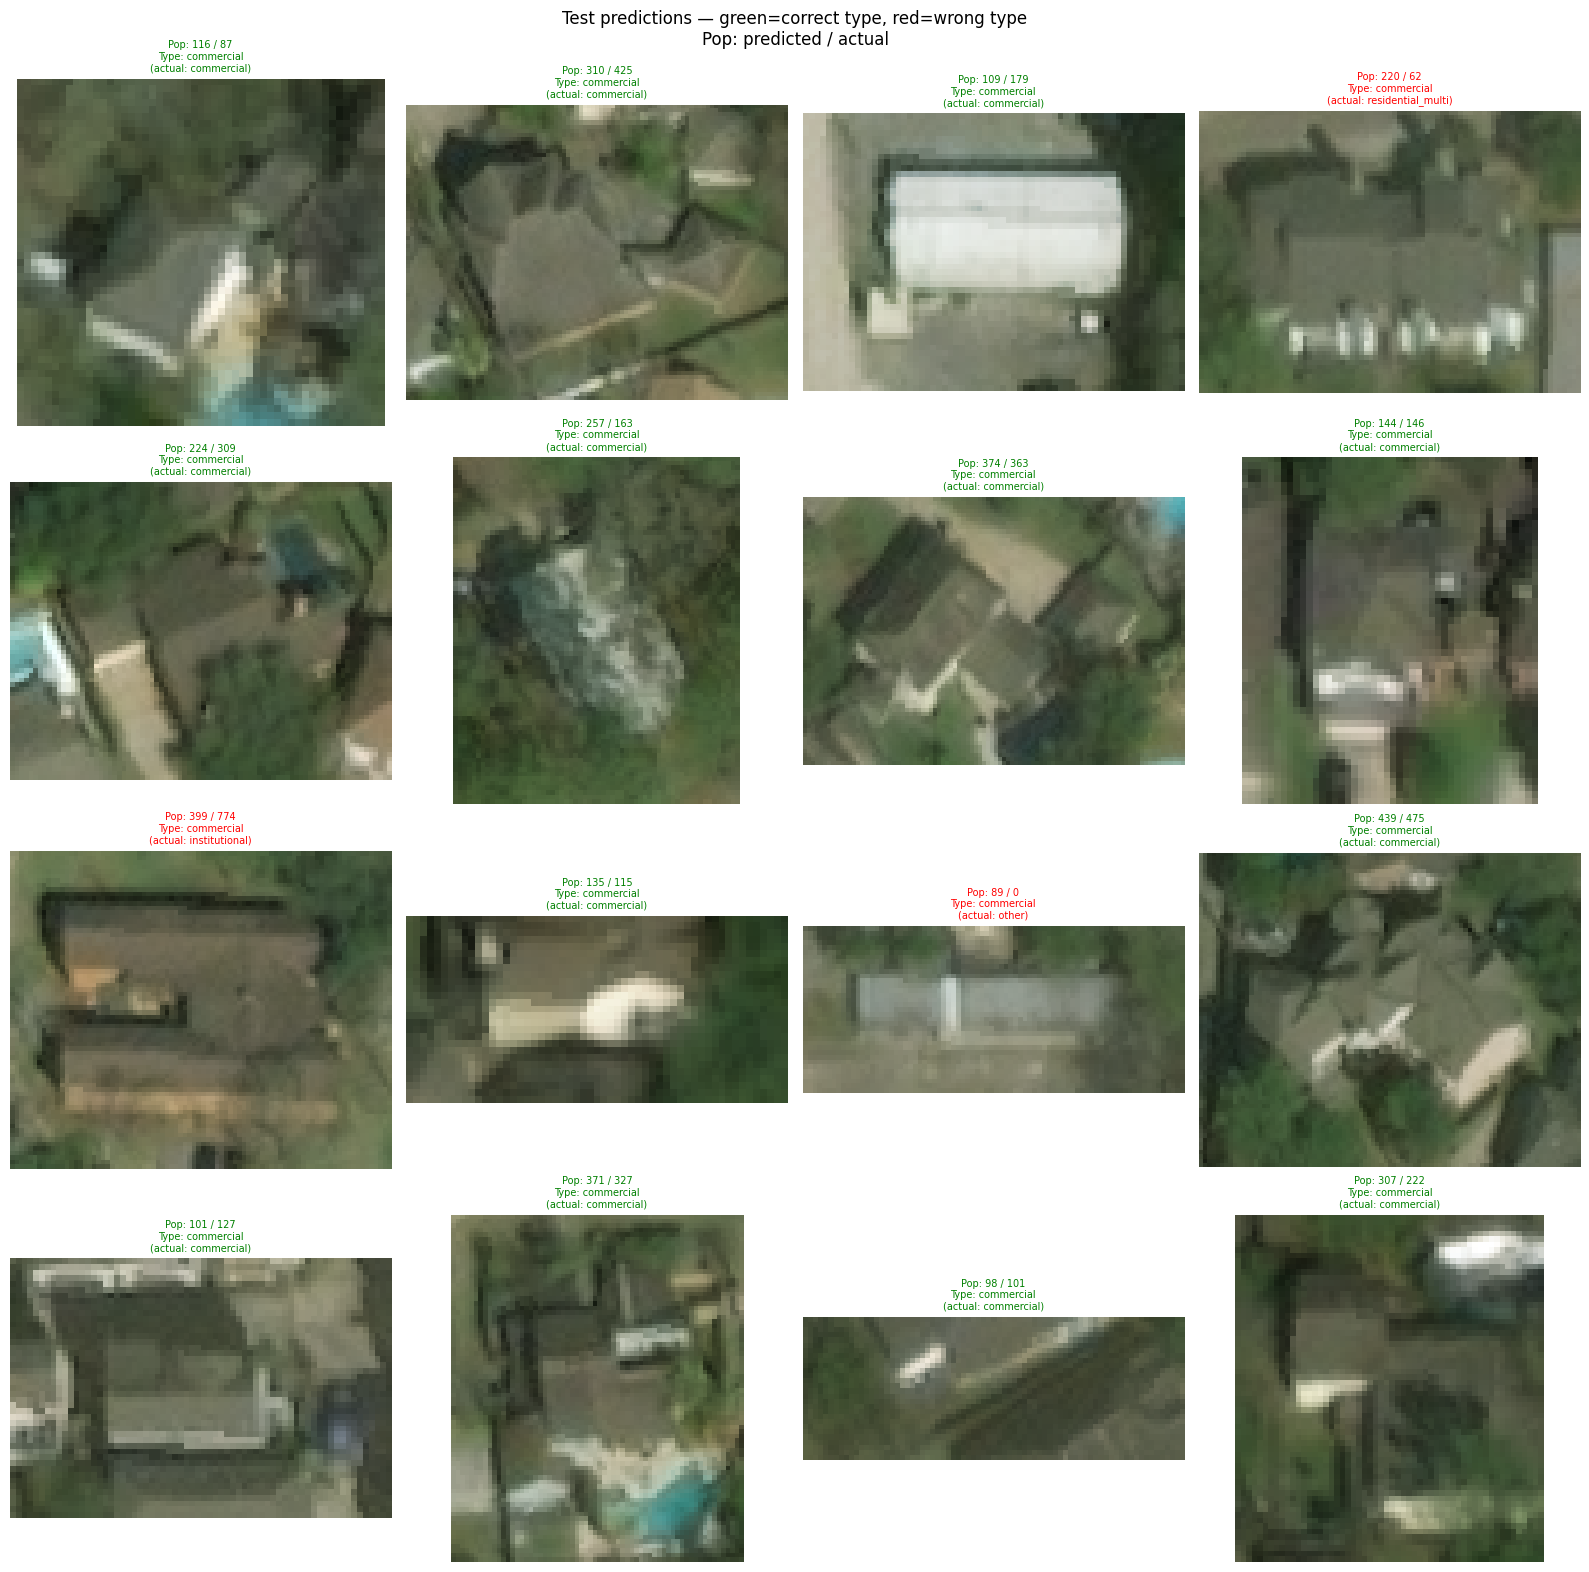

In [15]:
# Show random test buildings with predictions vs ground truth

n_show = min(16, len(test_df))
show_idx = random.sample(range(len(test_df)), n_show)

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for ax, idx in zip(axes.flat, show_idx):
    row = test_df.iloc[idx]
    img = Image.open(row["crop_path"])
    ax.imshow(img)

    pred_pop  = test_metrics["pop_pred_real"][idx]
    true_pop  = np.expm1(test_ds.pop_targets[idx].item())
    pred_type = CLASS_NAMES[test_metrics["type_pred"][idx]]
    true_type = CLASS_NAMES[test_metrics["type_true"][idx]]

    color = "green" if pred_type == true_type else "red"
    ax.set_title(
        f"Pop: {pred_pop:.0f} / {true_pop:.0f}\n"
        f"Type: {pred_type}\n(actual: {true_type})",
        fontsize=7, color=color,
    )
    ax.axis("off")

fig.suptitle("Test predictions — green=correct type, red=wrong type\n"
             "Pop: predicted / actual", fontsize=12)
plt.tight_layout()
plt.show()